In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr

# Annual components

In [157]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500 = z500.sel(time=slice('2000.1', '2017.12'))['z']

loc = (slice(None),) + (24, 5)
df = pd.Series(z500[loc].values, index=z500['time'].values)
print(f'Latitude: {z500[loc].lat.values}, Longitude: {z500[loc].lon.values}')
df.index.freq = 'h'

Latitude: 47.8125, Longitude: 28.125


In [158]:
from scipy.signal import periodogram, find_peaks

fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(df.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=100)
peak_freqs = freqs[peaks]
peak_periods = 1 / peak_freqs
peak_periods = peak_periods[peak_periods < 24*365*2]
peak_powers = power[peaks]
for i, (f, p) in enumerate(zip(peak_freqs, peak_powers)):
    if i > 10: break
    print(f"Peak at period = {1/f:<8.2f} hrs, power = {p:.5e}")

Peak at period = 8766.67  hrs, power = 1.99429e+11
Peak at period = 744.34   hrs, power = 1.20310e+09
Peak at period = 475.30   hrs, power = 6.27693e+08
Peak at period = 364.43   hrs, power = 3.35191e+08
Peak at period = 284.32   hrs, power = 2.30756e+08
Peak at period = 239.45   hrs, power = 2.58315e+08
Peak at period = 203.61   hrs, power = 2.11206e+08
Peak at period = 178.51   hrs, power = 2.46064e+08
Peak at period = 160.20   hrs, power = 1.57409e+08
Peak at period = 145.17   hrs, power = 6.22052e+07
Peak at period = 131.28   hrs, power = 1.87560e+08


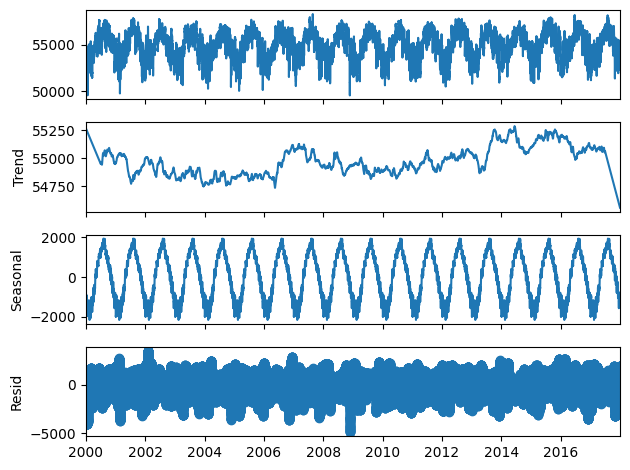

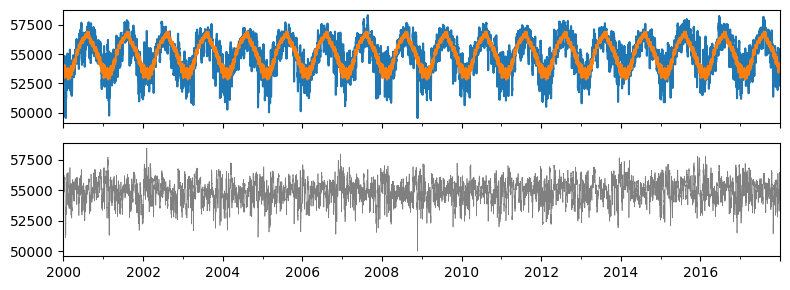

In [159]:
from statsmodels.tsa.seasonal import seasonal_decompose

res = seasonal_decompose(df, model='additive', extrapolate_trend=True, period=8767)
trend = res.trend
seasonal = res.seasonal
residual = df - seasonal

res.plot()

# Ignore the trend, just plot the seasonal component and the (original - seasonal) residual
fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
df.plot(ax=axs[0])
(df.mean() + seasonal).plot(ax=axs[0])
(residual).plot(lw=.5, color='gray', ax=axs[1])
fig.tight_layout()

Peak at period = 878.40   hrs, power = 8.72735e+08
Peak at period = 64.12    hrs, power = 2.06775e+07
Peak at period = 35.42    hrs, power = 1.01527e+06
Peak at period = 24.00    hrs, power = 1.04742e+07
Peak at period = 18.53    hrs, power = 1.78789e+05
Peak at period = 14.81    hrs, power = 1.48937e+05
Peak at period = 12.00    hrs, power = 1.91412e+06
Peak at period = 10.48    hrs, power = 3.59790e+04
Peak at period = 9.12     hrs, power = 1.78315e+04
Peak at period = 7.99     hrs, power = 5.39215e+04
Peak at period = 7.08     hrs, power = 9.35413e+03


Text(0, 0.5, 'Residual')

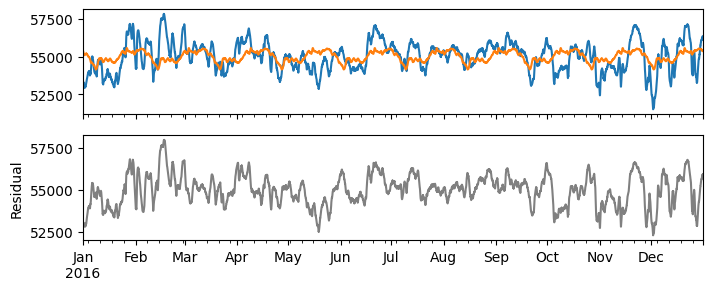

In [134]:
# Look at a single year
residual_year = residual.loc['2016':'2016']
freqs, power = periodogram(residual_year.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=100)
peak_freqs = freqs[peaks]
peak_periods = 1 / peak_freqs
peak_periods = peak_periods[peak_periods < 24*365*2]
peak_powers = power[peaks]
for i, (f, p) in enumerate(zip(peak_freqs, peak_powers)):
    if i > 10: break
    print(f"Peak at period = {1/f:<8.2f} hrs, power = {p:.5e}")

res = seasonal_decompose(residual_year, model='additive', extrapolate_trend=True, period=878)
trend = res.trend
seasonal = res.seasonal

fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
ax, ax1 = axs
residual_year.plot(ax=ax)
(residual_year.mean() + seasonal).plot(ax=ax)
(residual_year - seasonal).plot(ax=ax1, color='gray')

ax1.set_ylabel('Residual')

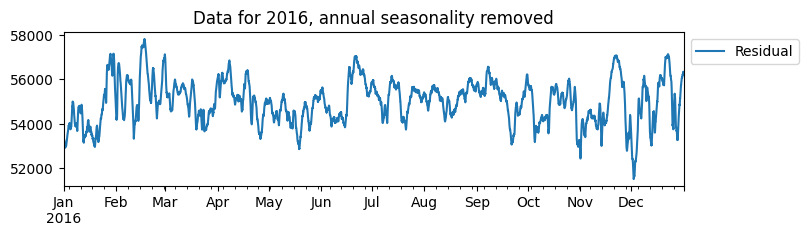

In [167]:
fig, ax = plt.subplots(figsize=(8, 2))
# df.loc['2016':'2016'].plot(label='Original')
residual.loc['2016':'2016'].plot(ax=ax, color='C0', label='Residual')
ax.set_title('Data for 2016, annual seasonality removed')
ax.legend(bbox_to_anchor=(1, 1))

# Fitting a GP to the residuals
Not implemented yet, unclear if this is a good idea when residuals are quite large

In [153]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2000.1', '2011.12'))['z']
z500_test = z500.sel(time=slice('2012.1', '2017.12'))['z']

In [154]:
loc = (slice(None),) + (24, 5)
df_train = pd.Series(z500_train[loc].values, index=z500_train['time'].values)
print(f'Latitude: {z500_train[loc].lat.values}, Longitude: {z500_train[loc].lon.values}')
df_train.index.freq = 'h'

Latitude: 47.8125, Longitude: 28.125


Extract annual seasonality and subtract to get residuals

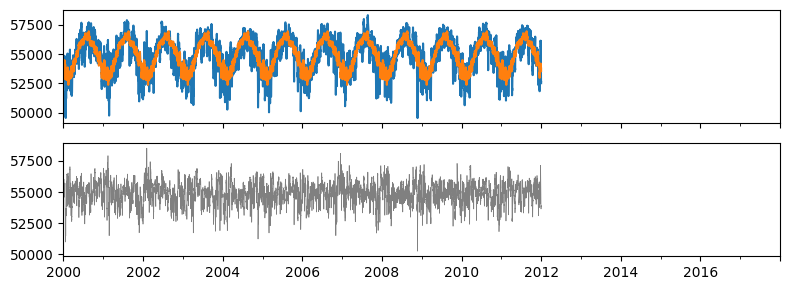

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

res = seasonal_decompose(df_train, model='additive', extrapolate_trend=True, period=8767)
trend = res.trend
seasonal = res.seasonal
residual = df_train - seasonal

fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
df_train.plot(ax=axs[0])
(df_train.mean() + seasonal).plot(ax=axs[0])
(residual).plot(lw=.5, color='gray', ax=axs[1])

for ax in axs:
    ax.set_xlim(z500_train['time'].values[0], z500_test['time'].values[-1])

fig.tight_layout()